# Comparing Land Surface Temperature and Heat Index Patterns Across Two U.S. Cities

## Project Goal

This project compares satellite-based Land Surface Temperature (LST) and humidity-informed Heat Index (HI) patterns across two U.S. cities: Phoenix and Miami.

The goal is to understand whether adding humidity changes the spatial interpretation of urban heat exposure. This notebook is designed for the GEOG573 final project and also serves as a reusable workflow for a future research paper on neighborhood heat exposure inequities.

## Research Questions

1. How do LST-based and humidity-adjusted heat exposure measures differ across cities from different climate zones?
2. How does the spatial pattern of urban heat change when moving from satellite-based LST to a humidity-informed measure such as Heat Index?

## Planned Workflow

1. Define study areas for Phoenix and Miami.
2. Retrieve MODIS LST data from Google Earth Engine.
3. Retrieve temperature and humidity-related data from ERA5.
4. Calculate Heat Index.
5. Compare LST and Heat Index using summary statistics, maps, and plots.
6. Examine whether spatial heat patterns differ within and across cities.

## Literature-Informed Method Design

#This workflow is based on two main ideas from previous research. First, Wang et al. (2023) show that heat exposure should not be measured only by air temperature, because humidity affects the human body's ability to dissipate heat. Their study uses Heat Index (HI), which combines temperature and relative humidity, to represent human-perceived heat stress. Second, Hsu et al. (2021) show that satellite-based urban heat measures can be combined with census tract-level demographic data to study spatial inequality in urban heat exposure. Their framework motivates future tract-level analysis of heat exposure inequality. In this project, we start with a simpler two-city comparison of LST and Heat Index. This serves as a pilot workflow before extending the analysis to tract-level inequality and more cities.

In [1]:
# Check Python environment
import sys

print(sys.executable)
print(sys.version)

/opt/anaconda3/bin/python
3.13.9 | packaged by Anaconda, Inc. | (main, Oct 21 2025, 19:11:29) [Clang 20.1.8 ]


In [2]:
# Import required packages
import ee
import geemap
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt

print("All packages imported successfully.")

All packages imported successfully.


In [3]:
# Initialize Google Earth Engine
ee.Initialize(project="yufei-gee-lab6")

print("Earth Engine initialized successfully.")

Earth Engine initialized successfully.


In [4]:
import sys
print(sys.executable)
print(sys.version)

/opt/anaconda3/bin/python
3.13.9 | packaged by Anaconda, Inc. | (main, Oct 21 2025, 19:11:29) [Clang 20.1.8 ]


In [5]:
import ee
import geemap
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt

print("All imports worked.")

All imports worked.


In [6]:
import ee
print("ee imported")
print(ee.__version__)

ee imported
1.7.16


## Study Areas

We start with two U.S. cities that represent contrasting climate contexts:

- Phoenix, Arizona: hot and dry climate
- Miami, Florida: hot and humid climate

This contrast helps us test whether adding humidity changes the spatial interpretation of urban heat exposure.

In [7]:
# Define study areas for Phoenix and Miami

cities = {
    "Phoenix": {
        "center": [33.45, -112.07],
        "geometry": ee.Geometry.Rectangle([-112.35, 33.20, -111.85, 33.75])
    },
    "Miami": {
        "center": [25.76, -80.19],
        "geometry": ee.Geometry.Rectangle([-80.45, 25.55, -80.05, 25.95])
    }
}

print("Cities defined:")
for city_name in cities:
    print("-", city_name)

Cities defined:
- Phoenix
- Miami


## MODIS Land Surface Temperature Processing

We use MODIS daytime Land Surface Temperature (LST) as the satellite-based surface heat measure. LST reflects the temperature of the land surface and is commonly used to study urban heat patterns.

In this workflow, we calculate the summer mean daytime LST for each city and convert the MODIS LST values from Kelvin to Celsius.

In [8]:
# Function to get summer daytime LST from MODIS

def get_summer_lst(city_geom, start_date="2023-06-01", end_date="2023-08-31"):
    """
    Get summer daytime Land Surface Temperature (LST) from MODIS.

    MODIS LST_Day_1km is stored in Kelvin with a scale factor of 0.02.
    This function converts it to Celsius and clips it to the study area.
    """

    modis = (
        ee.ImageCollection("MODIS/061/MOD11A2")
        .filterBounds(city_geom)
        .filterDate(start_date, end_date)
        .select("LST_Day_1km")
    )

    lst_c = (
        modis.mean()
        .multiply(0.02)
        .subtract(273.15)
        .rename("LST_C")
        .clip(city_geom)
    )

    return lst_c

print("LST function ready.")

LST function ready.


In [9]:
# Test LST function for both cities

phoenix_lst = get_summer_lst(cities["Phoenix"]["geometry"])
miami_lst = get_summer_lst(cities["Miami"]["geometry"])

print("Phoenix and Miami LST layers created.")

Phoenix and Miami LST layers created.


## Heat Index Processing

Heat Index (HI) combines air temperature and relative humidity to approximate human-perceived heat stress. This is useful because temperature alone may not fully represent how heat is experienced by people.

Following human-perceived heatwave studies, we use ERA5 temperature and dewpoint temperature to estimate relative humidity and then calculate Heat Index.

In [10]:
# Function to calculate Heat Index from ERA5 temperature and dewpoint

def get_heat_index(city_geom, start_date="2023-06-01", end_date="2023-08-31"):
    """
    Calculate summer Heat Index using ERA5 daily data.

    Steps:
    1. Get mean 2m air temperature.
    2. Get mean dewpoint temperature.
    3. Estimate relative humidity from air temperature and dewpoint.
    4. Calculate Heat Index using the Rothfusz regression formula.
    5. Convert Heat Index from Fahrenheit to Celsius.
    """

    era5 = (
        ee.ImageCollection("ECMWF/ERA5/DAILY")
        .filterBounds(city_geom)
        .filterDate(start_date, end_date)
    )

    # 2m air temperature in Celsius
    t2m_c = (
        era5.select("mean_2m_air_temperature")
        .mean()
        .subtract(273.15)
        .rename("Air_Temp_C")
        .clip(city_geom)
    )

    # Dewpoint temperature in Celsius
    td_c = (
        era5.select("dewpoint_2m_temperature")
        .mean()
        .subtract(273.15)
        .rename("Dewpoint_C")
        .clip(city_geom)
    )

    # Estimate relative humidity (%) from air temperature and dewpoint
    rh = td_c.expression(
        "100 * exp((17.625 * td) / (243.04 + td) - (17.625 * t) / (243.04 + t))",
        {
            "t": t2m_c,
            "td": td_c
        }
    ).rename("Relative_Humidity").clip(city_geom)

    # Convert air temperature from Celsius to Fahrenheit
    t_f = t2m_c.multiply(9 / 5).add(32)

    # Rothfusz Heat Index formula in Fahrenheit
    hi_f = t_f.expression(
        """
        -42.379
        + 2.04901523 * T
        + 10.14333127 * RH
        - 0.22475541 * T * RH
        - 0.00683783 * T * T
        - 0.05481717 * RH * RH
        + 0.00122874 * T * T * RH
        + 0.00085282 * T * RH * RH
        - 0.00000199 * T * T * RH * RH
        """,
        {
            "T": t_f,
            "RH": rh
        }
    )

    # Convert Heat Index back to Celsius
    hi_c = (
        hi_f.subtract(32)
        .multiply(5 / 9)
        .rename("Heat_Index_C")
        .clip(city_geom)
    )

    return hi_c, t2m_c, rh

print("Heat Index function ready.")

Heat Index function ready.


In [11]:
# Test Heat Index function for both cities

phoenix_hi, phoenix_air_temp, phoenix_rh = get_heat_index(cities["Phoenix"]["geometry"])
miami_hi, miami_air_temp, miami_rh = get_heat_index(cities["Miami"]["geometry"])

print("Phoenix and Miami Heat Index layers created.")

Phoenix and Miami Heat Index layers created.


## Summary Statistics

We calculate summary statistics for each city and each heat measure. These results help us compare whether LST and Heat Index show different levels of spatial variability within the same city and across cities.

## Analysis Period

For this pilot workflow, we use summer 2019 (June 1 to August 31) because both MODIS LST and ERA5 daily meteorological data are available for this period in Google Earth Engine. Using the same time period keeps the LST and Heat Index comparison consistent.

In [12]:
# Set a common analysis period for both LST and Heat Index

START_DATE = "2019-06-01"
END_DATE = "2019-08-31"

# Re-create LST layers using the same analysis period
phoenix_lst = get_summer_lst(
    cities["Phoenix"]["geometry"],
    start_date=START_DATE,
    end_date=END_DATE
)

miami_lst = get_summer_lst(
    cities["Miami"]["geometry"],
    start_date=START_DATE,
    end_date=END_DATE
)

# Re-create Heat Index layers using the same analysis period
phoenix_hi, phoenix_air_temp, phoenix_rh = get_heat_index(
    cities["Phoenix"]["geometry"],
    start_date=START_DATE,
    end_date=END_DATE
)

miami_hi, miami_air_temp, miami_rh = get_heat_index(
    cities["Miami"]["geometry"],
    start_date=START_DATE,
    end_date=END_DATE
)

print("LST and Heat Index layers created for summer 2019.")

LST and Heat Index layers created for summer 2019.


In [13]:
# Function to calculate summary statistics for one image band

def get_image_stats(image, city_geom, band_name, scale=1000):
    """
    Calculate mean, min, max, and range for one image band within a city geometry.
    """

    stats = image.reduceRegion(
        reducer=(
            ee.Reducer.mean()
            .combine(reducer2=ee.Reducer.min(), sharedInputs=True)
            .combine(reducer2=ee.Reducer.max(), sharedInputs=True)
        ),
        geometry=city_geom,
        scale=scale,
        maxPixels=1e9
    )

    mean_value = stats.get(f"{band_name}_mean").getInfo()
    min_value = stats.get(f"{band_name}_min").getInfo()
    max_value = stats.get(f"{band_name}_max").getInfo()

    return mean_value, min_value, max_value, max_value - min_value


print("Summary statistics function ready.")

Summary statistics function ready.


In [14]:
# Calculate summary statistics for Phoenix and Miami

summary_rows = []

city_layers = {
    "Phoenix": {
        "geometry": cities["Phoenix"]["geometry"],
        "LST": phoenix_lst,
        "Heat_Index": phoenix_hi,
        "Air_Temp": phoenix_air_temp,
        "Relative_Humidity": phoenix_rh
    },
    "Miami": {
        "geometry": cities["Miami"]["geometry"],
        "LST": miami_lst,
        "Heat_Index": miami_hi,
        "Air_Temp": miami_air_temp,
        "Relative_Humidity": miami_rh
    }
}

for city_name, city_data in city_layers.items():
    geom = city_data["geometry"]

    # LST, unit: Celsius
    mean_v, min_v, max_v, range_v = get_image_stats(
        city_data["LST"], geom, "LST_C", scale=1000
    )
    summary_rows.append({
        "City": city_name,
        "Measure": "LST",
        "Unit": "C",
        "Mean": mean_v,
        "Min": min_v,
        "Max": max_v,
        "Range": range_v
    })

    # Heat Index, unit: Celsius
    mean_v, min_v, max_v, range_v = get_image_stats(
        city_data["Heat_Index"], geom, "Heat_Index_C", scale=10000
    )
    summary_rows.append({
        "City": city_name,
        "Measure": "Heat Index",
        "Unit": "C",
        "Mean": mean_v,
        "Min": min_v,
        "Max": max_v,
        "Range": range_v
    })

    # Air temperature, unit: Celsius
    mean_v, min_v, max_v, range_v = get_image_stats(
        city_data["Air_Temp"], geom, "Air_Temp_C", scale=10000
    )
    summary_rows.append({
        "City": city_name,
        "Measure": "Air Temperature",
        "Unit": "C",
        "Mean": mean_v,
        "Min": min_v,
        "Max": max_v,
        "Range": range_v
    })

    # Relative humidity, unit: percent
    mean_v, min_v, max_v, range_v = get_image_stats(
        city_data["Relative_Humidity"], geom, "Relative_Humidity", scale=10000
    )
    summary_rows.append({
        "City": city_name,
        "Measure": "Relative Humidity",
        "Unit": "%",
        "Mean": mean_v,
        "Min": min_v,
        "Max": max_v,
        "Range": range_v
    })

summary_df = pd.DataFrame(summary_rows)

# Round values
summary_df[["Mean", "Min", "Max", "Range"]] = summary_df[["Mean", "Min", "Max", "Range"]].round(2)

summary_df

,City,Measure,Unit,Mean,Min,Max,Range
0,Phoenix,LST,C,49.57,41.95,54.68,12.73
1,Phoenix,Heat Index,C,31.85,31.05,32.46,1.41
2,Phoenix,Air Temperature,C,33.94,33.15,34.56,1.41
3,Phoenix,Relative Humidity,%,19.34,19.01,20.22,1.21
4,Miami,LST,C,35.40,26.82,40.64,13.82
5,Miami,Heat Index,C,32.06,31.95,32.21,0.26
6,Miami,Air Temperature,C,28.10,27.98,28.15,0.17
7,Miami,Relative Humidity,%,78.23,77.40,79.41,2.01


## Comparison Plots

To make the comparison clearer, we create two summary plots:

1. Mean comparison: compares the average LST and Heat Index across Phoenix and Miami.
2. Spatial range comparison: compares how much each heat measure varies within each city.

These plots help show that LST and Heat Index may lead to different interpretations of urban heat exposure.

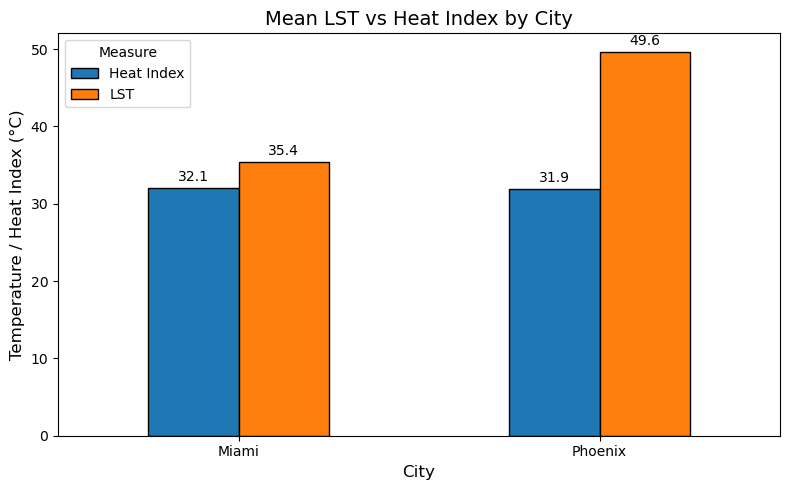

In [15]:
# Create a cleaner mean comparison plot for LST and Heat Index

import os

# Create figures folder if it does not exist
os.makedirs("../figures", exist_ok=True)

# Keep only LST and Heat Index
plot_df = summary_df[summary_df["Measure"].isin(["LST", "Heat Index"])].copy()

# Pivot table for plotting
mean_plot_df = plot_df.pivot(index="City", columns="Measure", values="Mean")

ax = mean_plot_df.plot(
    kind="bar",
    figsize=(8, 5),
    edgecolor="black"
)

ax.set_title("Mean LST vs Heat Index by City", fontsize=14)
ax.set_xlabel("City", fontsize=12)
ax.set_ylabel("Temperature / Heat Index (°C)", fontsize=12)
ax.tick_params(axis="x", rotation=0)
ax.legend(title="Measure")

# Add value labels on bars
for container in ax.containers:
    ax.bar_label(container, fmt="%.1f", padding=3)

plt.tight_layout()
plt.savefig("../figures/mean_lst_vs_heat_index_by_city.png", dpi=300, bbox_inches="tight")
plt.show()

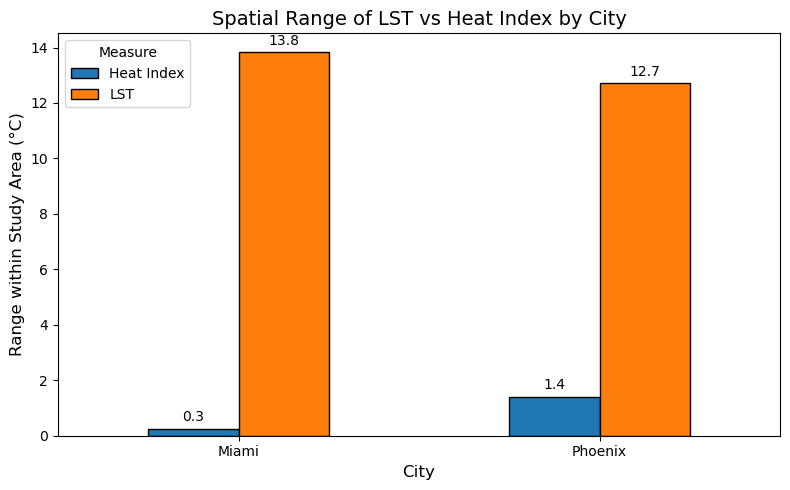

In [16]:
# Create a cleaner spatial range comparison plot for LST and Heat Index

range_plot_df = plot_df.pivot(index="City", columns="Measure", values="Range")

ax = range_plot_df.plot(
    kind="bar",
    figsize=(8, 5),
    edgecolor="black"
)

ax.set_title("Spatial Range of LST vs Heat Index by City", fontsize=14)
ax.set_xlabel("City", fontsize=12)
ax.set_ylabel("Range within Study Area (°C)", fontsize=12)
ax.tick_params(axis="x", rotation=0)
ax.legend(title="Measure")

# Add value labels on bars
for container in ax.containers:
    ax.bar_label(container, fmt="%.1f", padding=3)

plt.tight_layout()
plt.savefig("../figures/range_lst_vs_heat_index_by_city.png", dpi=300, bbox_inches="tight")
plt.show()

## Spatial Pattern Maps

We create separate maps for LST and Heat Index in Phoenix and Miami. These maps help compare whether satellite-based surface heat and humidity-informed human heat stress show different spatial patterns.

In [17]:
# Phoenix LST map

lst_vis = {
    "min": 25,
    "max": 55,
    "palette": ["#ffffcc", "#ffeda0", "#feb24c", "#fd8d3c", "#f03b20", "#bd0026"]
}

Map_phx_lst = geemap.Map(center=cities["Phoenix"]["center"], zoom=9)
Map_phx_lst.add_basemap("CartoDB.Positron")
Map_phx_lst.addLayer(phoenix_lst, lst_vis, "Phoenix LST (C)")
Map_phx_lst.addLayer(cities["Phoenix"]["geometry"], {"color": "black"}, "Phoenix Study Area")
Map_phx_lst.add_colorbar(lst_vis, label="LST (°C)")
Map_phx_lst

Map(center=[33.45, -112.07], controls=(WidgetControl(options=['position', 'transparent_bg'], position='toprigh…

In [18]:
# Phoenix Heat Index map

hi_vis = {
    "min": 28,
    "max": 35,
    "palette": ["#f7fbff", "#c6dbef", "#6baed6", "#3182bd", "#08519c"]
}

Map_phx_hi = geemap.Map(center=cities["Phoenix"]["center"], zoom=9)
Map_phx_hi.add_basemap("CartoDB.Positron")
Map_phx_hi.addLayer(phoenix_hi, hi_vis, "Phoenix Heat Index (C)")
Map_phx_hi.addLayer(cities["Phoenix"]["geometry"], {"color": "black"}, "Phoenix Study Area")
Map_phx_hi.add_colorbar(hi_vis, label="Heat Index (°C)")
Map_phx_hi

Map(center=[33.45, -112.07], controls=(WidgetControl(options=['position', 'transparent_bg'], position='toprigh…

In [19]:
# Miami LST map

Map_mia_lst = geemap.Map(center=cities["Miami"]["center"], zoom=10)
Map_mia_lst.add_basemap("CartoDB.Positron")
Map_mia_lst.addLayer(miami_lst, lst_vis, "Miami LST (C)")
Map_mia_lst.addLayer(cities["Miami"]["geometry"], {"color": "black"}, "Miami Study Area")
Map_mia_lst.add_colorbar(lst_vis, label="LST (°C)")
Map_mia_lst

Map(center=[25.76, -80.19], controls=(WidgetControl(options=['position', 'transparent_bg'], position='topright…

In [20]:
# Miami Heat Index map

Map_mia_hi = geemap.Map(center=cities["Miami"]["center"], zoom=10)
Map_mia_hi.add_basemap("CartoDB.Positron")
Map_mia_hi.addLayer(miami_hi, hi_vis, "Miami Heat Index (C)")
Map_mia_hi.addLayer(cities["Miami"]["geometry"], {"color": "black"}, "Miami Study Area")
Map_mia_hi.add_colorbar(hi_vis, label="Heat Index (°C)")
Map_mia_hi

Map(center=[25.76, -80.19], controls=(WidgetControl(options=['position', 'transparent_bg'], position='topright…

## Spatial Mismatch Between LST and Heat Index

To move beyond simple maps, we compare whether LST hotspots and Heat Index hotspots occur in the same locations.

For each city, we define hotspots as the top 20% highest-value pixels for each measure. We then compare:

- LST-only hotspots: areas identified as hot by LST but not by Heat Index
- Heat-Index-only hotspots: areas identified as hot by Heat Index but not by LST
- Overlap hotspots: areas identified as hot by both measures

This helps evaluate whether satellite-based surface heat and humidity-informed human heat stress identify the same high-risk areas.

In [21]:
# Function to calculate top-percentile hotspot overlap between LST and Heat Index

def get_hotspot_overlap(lst_img, hi_img, city_geom, city_name, percentile=80, scale=10000):
    """
    Compare top-percentile hotspots from LST and Heat Index.

    Hotspots are defined as pixels above the selected percentile.
    The result reports the area of:
    1. LST-only hotspots
    2. Heat-Index-only hotspots
    3. Overlap hotspots
    """

    # Get percentile thresholds
    lst_threshold = lst_img.reduceRegion(
        reducer=ee.Reducer.percentile([percentile]),
        geometry=city_geom,
        scale=scale,
        maxPixels=1e9
    ).get("LST_C")

    hi_threshold = hi_img.reduceRegion(
        reducer=ee.Reducer.percentile([percentile]),
        geometry=city_geom,
        scale=scale,
        maxPixels=1e9
    ).get("Heat_Index_C")

    lst_hotspot = lst_img.gte(ee.Number(lst_threshold)).rename("LST_hotspot")
    hi_hotspot = hi_img.gte(ee.Number(hi_threshold)).rename("HI_hotspot")

    overlap = lst_hotspot.And(hi_hotspot).rename("Overlap")
    lst_only = lst_hotspot.And(hi_hotspot.Not()).rename("LST_only")
    hi_only = hi_hotspot.And(lst_hotspot.Not()).rename("HI_only")

    pixel_area_km2 = ee.Image.pixelArea().divide(1e6)

    def area_km2(mask_img):
        area = pixel_area_km2.updateMask(mask_img).reduceRegion(
            reducer=ee.Reducer.sum(),
            geometry=city_geom,
            scale=scale,
            maxPixels=1e9
        ).get("area")
        return ee.Number(area).getInfo()

    result = {
        "City": city_name,
        "Percentile": percentile,
        "LST_threshold_C": ee.Number(lst_threshold).getInfo(),
        "HI_threshold_C": ee.Number(hi_threshold).getInfo(),
        "LST_only_hotspot_km2": area_km2(lst_only),
        "HI_only_hotspot_km2": area_km2(hi_only),
        "Overlap_hotspot_km2": area_km2(overlap)
    }

    return result, lst_hotspot, hi_hotspot, overlap, lst_only, hi_only


print("Hotspot overlap function ready.")

Hotspot overlap function ready.


In [22]:
# Calculate hotspot overlap for Phoenix and Miami

phoenix_overlap_result, phx_lst_hotspot, phx_hi_hotspot, phx_overlap, phx_lst_only, phx_hi_only = get_hotspot_overlap(
    phoenix_lst,
    phoenix_hi,
    cities["Phoenix"]["geometry"],
    "Phoenix",
    percentile=80,
    scale=10000
)

miami_overlap_result, mia_lst_hotspot, mia_hi_hotspot, mia_overlap, mia_lst_only, mia_hi_only = get_hotspot_overlap(
    miami_lst,
    miami_hi,
    cities["Miami"]["geometry"],
    "Miami",
    percentile=80,
    scale=10000
)

hotspot_df = pd.DataFrame([phoenix_overlap_result, miami_overlap_result])

# Round values
hotspot_df = hotspot_df.round(2)

hotspot_df

,City,Percentile,LST_threshold_C,HI_threshold_C,LST_only_hotspot_km2,HI_only_hotspot_km2,Overlap_hotspot_km2
0,Phoenix,80,50.33,32.39,447.31,1055.49,166.41
1,Miami,80,36.59,32.21,167.97,79.50,89.70


In [23]:
# Phoenix hotspot mismatch map

hotspot_vis = {
    "min": 1,
    "max": 3,
    "palette": [
        "#fdae61",  # LST-only
        "#2b83ba",  # HI-only
        "#d7191c"   # Overlap
    ]
}

# Create categorical image:
# 1 = LST-only
# 2 = HI-only
# 3 = overlap
phx_hotspot_category = (
    phx_lst_only.multiply(1)
    .add(phx_hi_only.multiply(2))
    .add(phx_overlap.multiply(3))
    .selfMask()
    .rename("Hotspot_Category")
)

Map_phx_hotspot = geemap.Map(center=cities["Phoenix"]["center"], zoom=9)
Map_phx_hotspot.add_basemap("CartoDB.Positron")
Map_phx_hotspot.addLayer(phx_hotspot_category, hotspot_vis, "Phoenix Hotspot Mismatch")
Map_phx_hotspot.addLayer(cities["Phoenix"]["geometry"], {"color": "black"}, "Phoenix Study Area")
Map_phx_hotspot

Map(center=[33.45, -112.07], controls=(WidgetControl(options=['position', 'transparent_bg'], position='toprigh…

In [24]:
# Miami hotspot mismatch map

mia_hotspot_category = (
    mia_lst_only.multiply(1)
    .add(mia_hi_only.multiply(2))
    .add(mia_overlap.multiply(3))
    .selfMask()
    .rename("Hotspot_Category")
)

Map_mia_hotspot = geemap.Map(center=cities["Miami"]["center"], zoom=10)
Map_mia_hotspot.add_basemap("CartoDB.Positron")
Map_mia_hotspot.addLayer(mia_hotspot_category, hotspot_vis, "Miami Hotspot Mismatch")
Map_mia_hotspot.addLayer(cities["Miami"]["geometry"], {"color": "black"}, "Miami Study Area")
Map_mia_hotspot

Map(center=[25.76, -80.19], controls=(WidgetControl(options=['position', 'transparent_bg'], position='topright…

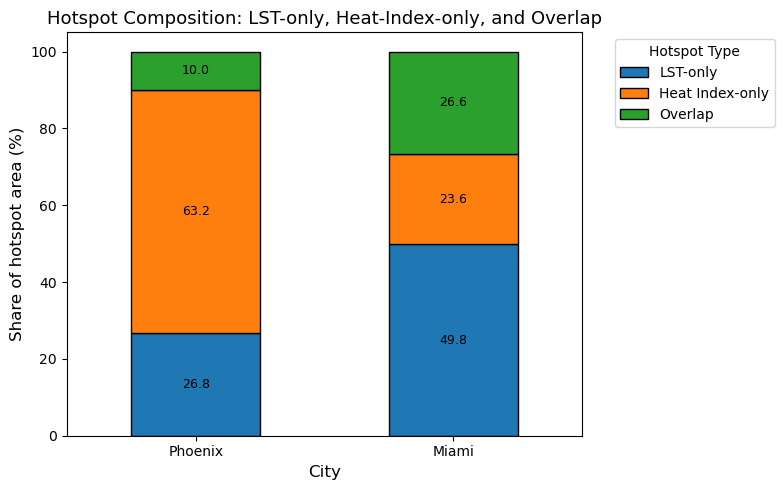

In [25]:
# Plot hotspot composition by city

# first compute percent columns from area columns
hotspot_plot_df = hotspot_df.copy()

hotspot_plot_df["Total_hotspot_km2"] = (
    hotspot_plot_df["LST_only_hotspot_km2"] +
    hotspot_plot_df["HI_only_hotspot_km2"] +
    hotspot_plot_df["Overlap_hotspot_km2"]
)

hotspot_plot_df["LST_only_percent"] = (
    hotspot_plot_df["LST_only_hotspot_km2"] / hotspot_plot_df["Total_hotspot_km2"] * 100
)

hotspot_plot_df["HI_only_percent"] = (
    hotspot_plot_df["HI_only_hotspot_km2"] / hotspot_plot_df["Total_hotspot_km2"] * 100
)

hotspot_plot_df["Overlap_percent"] = (
    hotspot_plot_df["Overlap_hotspot_km2"] / hotspot_plot_df["Total_hotspot_km2"] * 100
)

plot_df = hotspot_plot_df.set_index("City")[
    ["LST_only_percent", "HI_only_percent", "Overlap_percent"]
]

ax = plot_df.plot(
    kind="bar",
    stacked=True,
    figsize=(8, 5),
    edgecolor="black"
)

ax.set_title("Hotspot Composition: LST-only, Heat-Index-only, and Overlap", fontsize=13)
ax.set_xlabel("City", fontsize=12)
ax.set_ylabel("Share of hotspot area (%)", fontsize=12)
ax.tick_params(axis="x", rotation=0)

ax.legend(
    title="Hotspot Type",
    labels=["LST-only", "Heat Index-only", "Overlap"],
    bbox_to_anchor=(1.05, 1),
    loc="upper left"
)

for container in ax.containers:
    labels = []
    for v in container.datavalues:
        labels.append(f"{v:.1f}" if v >= 3 else "")
    ax.bar_label(container, labels=labels, label_type="center", fontsize=9)

plt.tight_layout()
plt.savefig("../figures/hotspot_composition_by_city.png", dpi=300, bbox_inches="tight")
plt.show()

## Hotspot Overlap Metrics

To quantify spatial mismatch more clearly, we calculate three overlap metrics:

- Overlap as a share of LST hotspots
- Overlap as a share of Heat Index hotspots
- Jaccard Index, defined as overlap area divided by the union of LST and Heat Index hotspot areas

A lower Jaccard Index means stronger spatial mismatch between the two heat measures.

In [26]:
# Calculate clearer hotspot overlap metrics

hotspot_metrics_df = hotspot_df.copy()

hotspot_metrics_df["LST_hotspot_total_km2"] = (
    hotspot_metrics_df["LST_only_hotspot_km2"] +
    hotspot_metrics_df["Overlap_hotspot_km2"]
)

hotspot_metrics_df["HI_hotspot_total_km2"] = (
    hotspot_metrics_df["HI_only_hotspot_km2"] +
    hotspot_metrics_df["Overlap_hotspot_km2"]
)

hotspot_metrics_df["Union_hotspot_km2"] = (
    hotspot_metrics_df["LST_only_hotspot_km2"] +
    hotspot_metrics_df["HI_only_hotspot_km2"] +
    hotspot_metrics_df["Overlap_hotspot_km2"]
)

hotspot_metrics_df["Overlap_pct_of_LST_hotspot"] = (
    hotspot_metrics_df["Overlap_hotspot_km2"] /
    hotspot_metrics_df["LST_hotspot_total_km2"] * 100
)

hotspot_metrics_df["Overlap_pct_of_HI_hotspot"] = (
    hotspot_metrics_df["Overlap_hotspot_km2"] /
    hotspot_metrics_df["HI_hotspot_total_km2"] * 100
)

hotspot_metrics_df["Jaccard_Index"] = (
    hotspot_metrics_df["Overlap_hotspot_km2"] /
    hotspot_metrics_df["Union_hotspot_km2"]
)

hotspot_metrics_df = hotspot_metrics_df.round(2)

hotspot_metrics_df[
    [
        "City",
        "LST_threshold_C",
        "HI_threshold_C",
        "LST_hotspot_total_km2",
        "HI_hotspot_total_km2",
        "Overlap_hotspot_km2",
        "Overlap_pct_of_LST_hotspot",
        "Overlap_pct_of_HI_hotspot",
        "Jaccard_Index"
    ]
]

,City,LST_threshold_C,HI_threshold_C,LST_hotspot_total_km2,HI_hotspot_total_km2,Overlap_hotspot_km2,Overlap_pct_of_LST_hotspot,Overlap_pct_of_HI_hotspot,Jaccard_Index
0,Phoenix,50.33,32.39,613.72,1221.9,166.41,27.11,13.62,0.10
1,Miami,36.59,32.21,257.67,169.2,89.70,34.81,53.01,0.27


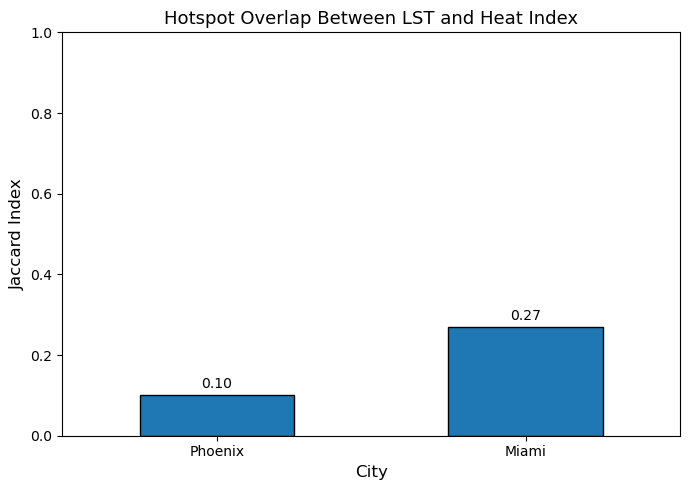

In [27]:
# Plot Jaccard Index by city

ax = hotspot_metrics_df.plot(
    x="City",
    y="Jaccard_Index",
    kind="bar",
    figsize=(7, 5),
    legend=False,
    edgecolor="black"
)

ax.set_title("Hotspot Overlap Between LST and Heat Index", fontsize=13)
ax.set_xlabel("City", fontsize=12)
ax.set_ylabel("Jaccard Index", fontsize=12)
ax.tick_params(axis="x", rotation=0)
ax.set_ylim(0, 1)

for container in ax.containers:
    ax.bar_label(container, fmt="%.2f", padding=3)

plt.tight_layout()
plt.savefig("../figures/hotspot_jaccard_index_by_city.png", dpi=300, bbox_inches="tight")
plt.show()

## Improve Study Area Boundaries

The initial pilot used rectangular bounding boxes for Phoenix and Miami. This is useful for testing the workflow, but it may include non-urban areas and water bodies, especially for Miami.

To make the analysis more reliable, we replace the rectangles with official Census place boundaries. This improves the interpretation of city-level LST, Heat Index, and hotspot overlap results.

In [28]:
# Load official Census place boundaries for Arizona and Florida

import geopandas as gpd

# State FIPS:
# Arizona = 04
# Florida = 12
az_places_url = "https://www2.census.gov/geo/tiger/GENZ2023/shp/cb_2023_04_place_500k.zip"
fl_places_url = "https://www2.census.gov/geo/tiger/GENZ2023/shp/cb_2023_12_place_500k.zip"

az_places_gdf = gpd.read_file(az_places_url)
fl_places_gdf = gpd.read_file(fl_places_url)

print("Arizona places:", az_places_gdf.shape)
print("Florida places:", fl_places_gdf.shape)

print(az_places_gdf.columns)

Arizona places: (467, 13)
Florida places: (955, 13)
Index(['STATEFP', 'PLACEFP', 'PLACENS', 'GEOIDFQ', 'GEOID', 'NAME', 'NAMELSAD',
       'STUSPS', 'STATE_NAME', 'LSAD', 'ALAND', 'AWATER', 'geometry'],
      dtype='object')


In [29]:
# Filter Phoenix, Arizona and Miami, Florida

phoenix_gdf = az_places_gdf[
    az_places_gdf["NAME"].str.lower() == "phoenix"
].copy()

miami_gdf = fl_places_gdf[
    fl_places_gdf["NAME"].str.lower() == "miami"
].copy()

print("Phoenix rows:", len(phoenix_gdf))
print("Miami rows:", len(miami_gdf))

display(phoenix_gdf[["NAME", "STATEFP", "PLACEFP", "geometry"]])
display(miami_gdf[["NAME", "STATEFP", "PLACEFP", "geometry"]])

Phoenix rows: 1
Miami rows: 1


,NAME,STATEFP,PLACEFP,geometry
6,Phoenix,04,55000,"MULTIPOLYGON (((-112.12626 33.36182, -112.1255..."


,NAME,STATEFP,PLACEFP,geometry
835,Miami,12,45000,"POLYGON ((-80.31577 25.76809, -80.31304 25.770..."


In [30]:
# Convert official city boundaries to Earth Engine geometries

phoenix_ee = geemap.geopandas_to_ee(phoenix_gdf)
miami_ee = geemap.geopandas_to_ee(miami_gdf)

phoenix_boundary = phoenix_ee.geometry()
miami_boundary = miami_ee.geometry()

cities_official = {
    "Phoenix": {
        "center": [33.45, -112.07],
        "geometry": phoenix_boundary
    },
    "Miami": {
        "center": [25.76, -80.19],
        "geometry": miami_boundary
    }
}

print("Official city boundaries created.")

Official city boundaries created.


In [31]:
# Check official city boundaries

Map_boundaries = geemap.Map(center=[30.0, -96.0], zoom=4)
Map_boundaries.add_basemap("CartoDB.Positron")

Map_boundaries.addLayer(
    phoenix_boundary,
    {"color": "red"},
    "Phoenix official boundary"
)

Map_boundaries.addLayer(
    miami_boundary,
    {"color": "blue"},
    "Miami official boundary"
)

Map_boundaries

Map(center=[30.0, -96.0], controls=(WidgetControl(options=['position', 'transparent_bg'], position='topright',…

## Re-run Analysis with Official City Boundaries

After replacing rectangular bounding boxes with official Census place boundaries, we re-run the LST and Heat Index workflow. This makes the city-level comparison more reliable and avoids including too much non-city area or ocean.

In [32]:
# Re-run LST and Heat Index workflow using official Census city boundaries

START_DATE = "2019-06-01"
END_DATE = "2019-08-31"

# Phoenix official boundary
phoenix_lst_official = get_summer_lst(
    cities_official["Phoenix"]["geometry"],
    start_date=START_DATE,
    end_date=END_DATE
)

phoenix_hi_official, phoenix_air_temp_official, phoenix_rh_official = get_heat_index(
    cities_official["Phoenix"]["geometry"],
    start_date=START_DATE,
    end_date=END_DATE
)

# Miami official boundary
miami_lst_official = get_summer_lst(
    cities_official["Miami"]["geometry"],
    start_date=START_DATE,
    end_date=END_DATE
)

miami_hi_official, miami_air_temp_official, miami_rh_official = get_heat_index(
    cities_official["Miami"]["geometry"],
    start_date=START_DATE,
    end_date=END_DATE
)

print("Official-boundary LST and Heat Index layers created.")

Official-boundary LST and Heat Index layers created.


In [33]:
# Calculate summary statistics using official city boundaries

official_summary_rows = []

official_city_layers = {
    "Phoenix": {
        "geometry": cities_official["Phoenix"]["geometry"],
        "LST": phoenix_lst_official,
        "Heat_Index": phoenix_hi_official,
        "Air_Temp": phoenix_air_temp_official,
        "Relative_Humidity": phoenix_rh_official
    },
    "Miami": {
        "geometry": cities_official["Miami"]["geometry"],
        "LST": miami_lst_official,
        "Heat_Index": miami_hi_official,
        "Air_Temp": miami_air_temp_official,
        "Relative_Humidity": miami_rh_official
    }
}

for city_name, city_data in official_city_layers.items():
    geom = city_data["geometry"]

    # LST
    mean_v, min_v, max_v, range_v = get_image_stats(
        city_data["LST"], geom, "LST_C", scale=1000
    )
    official_summary_rows.append({
        "City": city_name,
        "Measure": "LST",
        "Unit": "C",
        "Mean": mean_v,
        "Min": min_v,
        "Max": max_v,
        "Range": range_v
    })

    # Heat Index
    mean_v, min_v, max_v, range_v = get_image_stats(
        city_data["Heat_Index"], geom, "Heat_Index_C", scale=10000
    )
    official_summary_rows.append({
        "City": city_name,
        "Measure": "Heat Index",
        "Unit": "C",
        "Mean": mean_v,
        "Min": min_v,
        "Max": max_v,
        "Range": range_v
    })

    # Air Temperature
    mean_v, min_v, max_v, range_v = get_image_stats(
        city_data["Air_Temp"], geom, "Air_Temp_C", scale=10000
    )
    official_summary_rows.append({
        "City": city_name,
        "Measure": "Air Temperature",
        "Unit": "C",
        "Mean": mean_v,
        "Min": min_v,
        "Max": max_v,
        "Range": range_v
    })

    # Relative Humidity
    mean_v, min_v, max_v, range_v = get_image_stats(
        city_data["Relative_Humidity"], geom, "Relative_Humidity", scale=10000
    )
    official_summary_rows.append({
        "City": city_name,
        "Measure": "Relative Humidity",
        "Unit": "%",
        "Mean": mean_v,
        "Min": min_v,
        "Max": max_v,
        "Range": range_v
    })

official_summary_df = pd.DataFrame(official_summary_rows)
official_summary_df[["Mean", "Min", "Max", "Range"]] = official_summary_df[["Mean", "Min", "Max", "Range"]].round(2)

official_summary_df

,City,Measure,Unit,Mean,Min,Max,Range
0,Phoenix,LST,C,50.41,43.98,54.64,10.66
1,Phoenix,Heat Index,C,31.43,28.64,32.46,3.82
2,Phoenix,Air Temperature,C,33.49,30.44,34.56,4.12
3,Phoenix,Relative Humidity,%,19.51,19.01,21.09,2.08
4,Miami,LST,C,36.68,30.38,39.65,9.27
5,Miami,Heat Index,C,32.06,31.95,32.21,0.26
6,Miami,Air Temperature,C,28.07,27.98,28.15,0.17
7,Miami,Relative Humidity,%,78.59,77.40,79.41,2.01


## Official-Boundary Hotspot Mismatch Analysis

After improving the study areas with official Census city boundaries, we re-calculate hotspot mismatch between LST and Heat Index.

This step tests whether the hottest surface areas and the highest human-perceived heat stress areas overlap within each city.

In [34]:
# Official-boundary hotspot mismatch and overlap metrics

# Run hotspot overlap using official city boundaries
phoenix_official_overlap_result, phx_lst_hotspot_official, phx_hi_hotspot_official, phx_overlap_official, phx_lst_only_official, phx_hi_only_official = get_hotspot_overlap(
    phoenix_lst_official,
    phoenix_hi_official,
    cities_official["Phoenix"]["geometry"],
    "Phoenix",
    percentile=80,
    scale=10000
)

miami_official_overlap_result, mia_lst_hotspot_official, mia_hi_hotspot_official, mia_overlap_official, mia_lst_only_official, mia_hi_only_official = get_hotspot_overlap(
    miami_lst_official,
    miami_hi_official,
    cities_official["Miami"]["geometry"],
    "Miami",
    percentile=80,
    scale=10000
)

official_hotspot_df = pd.DataFrame([
    phoenix_official_overlap_result,
    miami_official_overlap_result
]).round(2)

# Add overlap metrics
official_hotspot_df["LST_hotspot_total_km2"] = (
    official_hotspot_df["LST_only_hotspot_km2"] +
    official_hotspot_df["Overlap_hotspot_km2"]
)

official_hotspot_df["HI_hotspot_total_km2"] = (
    official_hotspot_df["HI_only_hotspot_km2"] +
    official_hotspot_df["Overlap_hotspot_km2"]
)

official_hotspot_df["Union_hotspot_km2"] = (
    official_hotspot_df["LST_only_hotspot_km2"] +
    official_hotspot_df["HI_only_hotspot_km2"] +
    official_hotspot_df["Overlap_hotspot_km2"]
)

official_hotspot_df["Overlap_pct_of_LST_hotspot"] = (
    official_hotspot_df["Overlap_hotspot_km2"] /
    official_hotspot_df["LST_hotspot_total_km2"] * 100
)

official_hotspot_df["Overlap_pct_of_HI_hotspot"] = (
    official_hotspot_df["Overlap_hotspot_km2"] /
    official_hotspot_df["HI_hotspot_total_km2"] * 100
)

official_hotspot_df["Jaccard_Index"] = (
    official_hotspot_df["Overlap_hotspot_km2"] /
    official_hotspot_df["Union_hotspot_km2"]
)

official_hotspot_df = official_hotspot_df.round(2)

official_hotspot_df[
    [
        "City",
        "LST_threshold_C",
        "HI_threshold_C",
        "LST_hotspot_total_km2",
        "HI_hotspot_total_km2",
        "Overlap_hotspot_km2",
        "Overlap_pct_of_LST_hotspot",
        "Overlap_pct_of_HI_hotspot",
        "Jaccard_Index"
    ]
]

,City,LST_threshold_C,HI_threshold_C,LST_hotspot_total_km2,HI_hotspot_total_km2,Overlap_hotspot_km2,Overlap_pct_of_LST_hotspot,Overlap_pct_of_HI_hotspot,Jaccard_Index
0,Phoenix,50.76,32.39,328.64,556.99,165.43,50.34,29.7,0.23
1,Miami,36.59,32.21,45.02,31.66,31.66,70.32,100.0,0.70


In [35]:
from pathlib import Path

p = Path("../data/processed")

print("Exists:", p.exists())
print("Is directory:", p.is_dir())
print("Is file:", p.is_file())
print("Path:", p.resolve())

Exists: True
Is directory: True
Is file: False
Path: /Users/yufeizhou/Desktop/heat-exposure-compare/data/processed


In [36]:
from pathlib import Path

p = Path("../data/processed")

# Rename the wrong file if it exists
if p.exists() and p.is_file():
    p.rename("../data/processed_old_wrong_file")

# Create correct folder
p.mkdir(parents=True, exist_ok=True)

official_summary_df.to_csv(p / "official_city_summary_stats.csv", index=False)
official_hotspot_df.to_csv(p / "official_hotspot_overlap_metrics.csv", index=False)

print("Fixed and saved result tables.")
print(list(p.iterdir()))

Fixed and saved result tables.
[PosixPath('../data/processed/four_city_hotspot_summary.csv'), PosixPath('../data/processed/four_city_discussion_table.csv'), PosixPath('../data/processed/four_city_hotspot_sensitivity.csv'), PosixPath('../data/processed/official_city_summary_stats.csv'), PosixPath('../data/processed/four_city_ranking_summary.csv'), PosixPath('../data/processed/four_city_jaccard_stability_summary.csv'), PosixPath('../data/processed/official_hotspot_overlap_metrics.csv'), PosixPath('../data/processed/four_city_hotspot_percentage_summary.csv'), PosixPath('../data/processed/meeting_ready_four_city_summary.csv')]


In [37]:
from pathlib import Path

project_root = Path("..").resolve()

for path in [
    project_root / "README.md",
    project_root / "notebooks",
    project_root / "figures",
    project_root / "data" / "processed",
]:
    print(path, "exists:", path.exists(), "is_dir:", path.is_dir())

/Users/yufeizhou/Desktop/heat-exposure-compare/README.md exists: True is_dir: False
/Users/yufeizhou/Desktop/heat-exposure-compare/notebooks exists: True is_dir: True
/Users/yufeizhou/Desktop/heat-exposure-compare/figures exists: True is_dir: True
/Users/yufeizhou/Desktop/heat-exposure-compare/data/processed exists: True is_dir: True


## Extend the Pilot from Two Cities to Four Cities

To strengthen the preliminary analysis, we extend the comparison from two cities to four cities.

Current cities:
- Phoenix, Arizona
- Miami, Florida

New cities:
- Las Vegas, Nevada
- Houston, Texas

This extension helps us test whether the differences between LST and Heat Index are consistent across more hot-dry and hot-humid urban contexts.

In [38]:
# Load official Census place boundaries for Nevada and Texas

nv_places_url = "https://www2.census.gov/geo/tiger/GENZ2023/shp/cb_2023_32_place_500k.zip"
tx_places_url = "https://www2.census.gov/geo/tiger/GENZ2023/shp/cb_2023_48_place_500k.zip"

nv_places_gdf = gpd.read_file(nv_places_url)
tx_places_gdf = gpd.read_file(tx_places_url)

print("Nevada places:", nv_places_gdf.shape)
print("Texas places:", tx_places_gdf.shape)

Nevada places: (133, 13)
Texas places: (1863, 13)
